# **Experiment-4**  - Iris Dataset

**AIM:** To demonstrate the process of the decision tree construction for classification problems using python programming.

**Algorithm Description:**
*  A Decision Tree is a supervised machine learning algorithm used for classification and regression. It represents decisions using a tree-like structure consisting of root node, decision node, branch and leaf nodes. The model splits the dataset based on feature values using measures like Gini Index or Information Gain. This process continues recursively until a stopping condition is met. Decision trees are easy to interpret and are widely used in machine learning applications.

* In a decision tree, the root node contains the entire dataset, internal nodes apply conditions on features, branches represent decision outcomes, and leaf nodes store the final prediction.


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

**Load & Explore the dataset**

In [77]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/Datasets/Iris_v2.csv")
print("First 2 rows of the dataset:\n",df.head(2))
print("Shape of the Dataset:",df.shape)
print("Number of columns:\n",df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 2 rows of the dataset:
    ID   SL   SW   PL   PW Species
0   1  5.1  3.5  1.4  0.2  Setosa
1   2  4.9  3.0  1.4  0.2  Setosa
Shape of the Dataset: (154, 6)
Number of columns:
 Index(['ID', 'SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Drop unneccessary columns**

In [78]:
df=df.drop(columns=["ID"])
print("Shape of the dataset after dropping a column:",df.shape)
print("Columns in the dataset after dropping:",df.columns)

Shape of the dataset after dropping a column: (154, 5)
Columns in the dataset after dropping: Index(['SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Remove Duplicates**

In [79]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape of the dataset after removing duplicates:",df.shape)

Duplicate rows: 6
Shape of the dataset after removing duplicates: (148, 5)


**Handle missing values**

In [80]:
print(df.isna().sum())
df["SL"] = df["SL"].fillna(df["SL"].mean())
df["PL"] = df["PL"].fillna(df["PL"].mean())

SL         7
SW         0
PL         2
PW         0
Species    0
dtype: int64


**Detect & Remove outliers**

<Axes: >

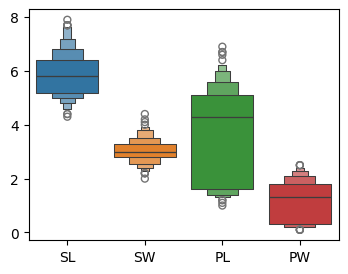

In [81]:
df1=df.copy()
plt.figure(figsize=(4,3))
sns.boxenplot(df1)

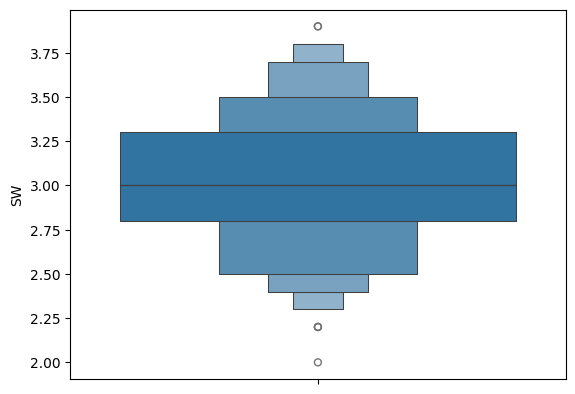

<Figure size 400x200 with 0 Axes>

In [82]:
df = df.loc[df["SW"] < 4]
sns.boxenplot(df['SW'])
plt.figure(figsize=(4,2))
plt.show()

**Applying Label Encoding to target column**

In [83]:
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Setosa': np.int64(0), 'Versicolor': np.int64(1), 'Virginica': np.int64(2)}


**Seperate features & Target Variables and Splitting the data into Training & Testing Sets**

In [84]:
X = df.iloc[:, :-1]
Y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

**Splitting the data into Training & Testing Sets**

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

**Initialize The Decision Tree Classifier**

In [86]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Predict Lables - Model evaluation**

In [87]:
y_pred = model.predict(X_test)
print(y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",classification_report(y_test, y_pred))
print("\nConfusion matric:\n",confusion_matrix(y_test,y_pred))

[2 2 0 1 0 1 0 0 2 1 2 0 0 1 2 1 1 0 0 1 2 0 1 1 2 1 1 1 2 0 0 0 2 2 1 1 1
 0 0 1 2 2 2 2]
Accuracy: 0.9318181818181818

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44


Confusion matric:
 [[14  0  0]
 [ 0 14  1]
 [ 0  2 13]]


**Model evaluation**

In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",classification_report(y_test, y_pred))
print("\nConfusion matric:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.9318181818181818

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44


Confusion matric:
 [[14  0  0]
 [ 0 14  1]
 [ 0  2 13]]


**Plotting Decision Tree**

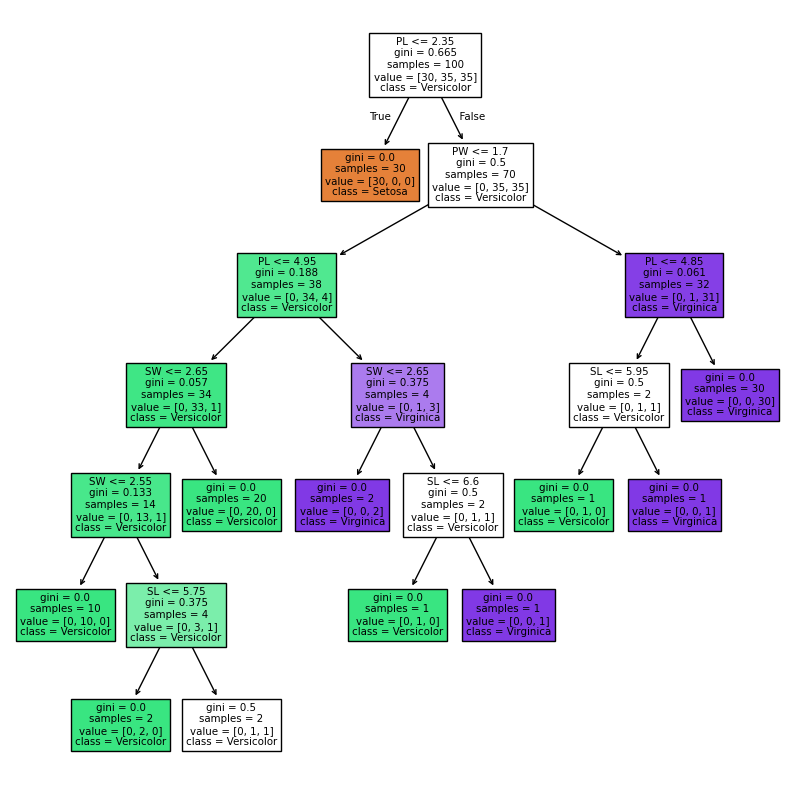

In [89]:
plt.figure(figsize=(10,10))
plot_tree(model, feature_names=X.columns,class_names=le.classes_, filled=True)
plt.show()

**Parameters in DecisionTreeClassifier**
* criterion: {“gini”, “entropy”, “log_loss”}, default=”gini”
* splitter: {“best”, “random”}, default=”best”
* max_depth: int, default=None

**Gini index Based (with best Spilt):**
* Gini Index measures impurity (lower value is better).
* Best splitter checks all possible splits and chooses the best.
* max_depth = None allows the tree to grow fully (may overfit)
* Formula: Gini=1−∑pi2​

In [90]:
dt_ginibest = DecisionTreeClassifier(criterion="gini",splitter="best",max_depth=None,random_state=42)
dt_ginibest.fit(X_train, y_train)
y_pred_ginibest = dt_ginibest.predict(X_test)
print("Gini Best Split Accuracy:", accuracy_score(y_test, y_pred_ginibest))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ginibest))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ginibest))

Gini Best Split Accuracy: 0.9318181818181818

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44


Confusion Matrix:
 [[14  0  0]
 [ 0 14  1]
 [ 0  2 13]]


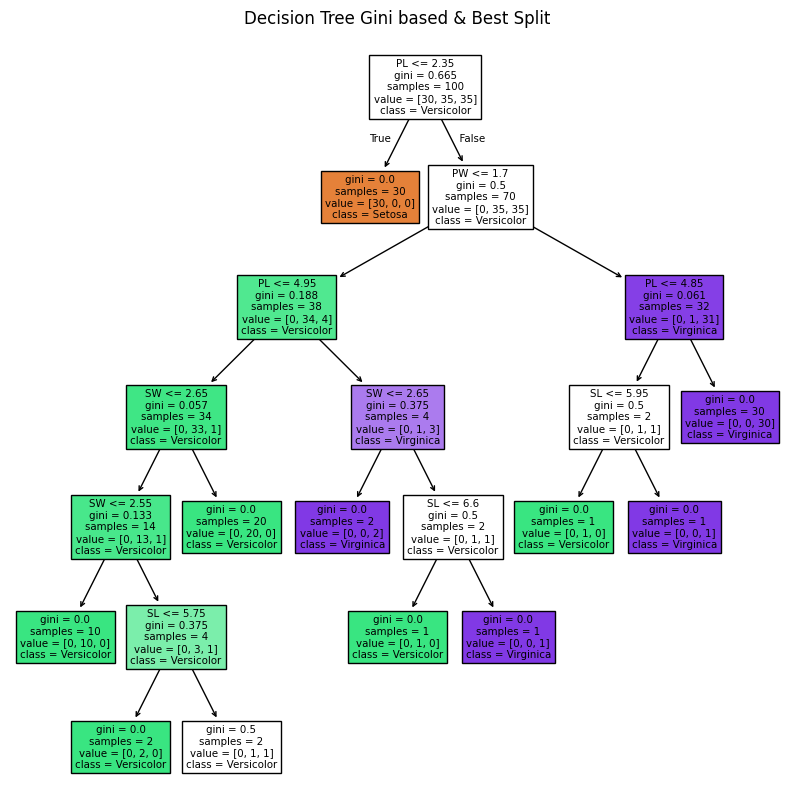

In [91]:
plt.figure(figsize=(10,10))
plot_tree(dt_ginibest,feature_names=X.columns,class_names=le.classes_,filled=True)
plt.title("Decision Tree Gini based & Best Split")
plt.show()

**Decision Tree with GIni Index Random Split:**
* Random splitter selects a random split among good splits
* max_depth = 3 controls tree growth
* Reduces overfitting and makes the tree smaller

In [92]:
dt_ginirandom = DecisionTreeClassifier(criterion="gini",splitter="random",max_depth=3,random_state=42)
dt_ginirandom.fit(X_train, y_train)
y_pred_ginirandom = dt_ginirandom.predict(X_test)
print("Gini Random Split Accuracy:", accuracy_score(y_test, y_pred_ginirandom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ginirandom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ginirandom))

Gini Random Split Accuracy: 0.9545454545454546

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.95        44
   macro avg       0.96      0.96      0.96        44
weighted avg       0.95      0.95      0.95        44


Confusion Matrix:
 [[14  0  0]
 [ 0 14  1]
 [ 0  1 14]]


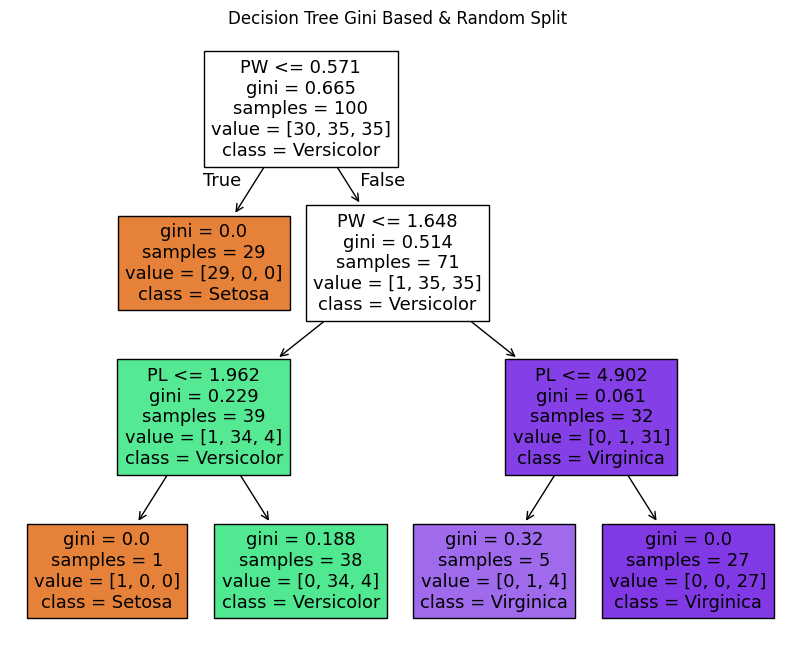

In [93]:
plt.figure(figsize=(10,8))
plot_tree( dt_ginirandom,feature_names=X.columns,class_names=le.classes_,filled=True)
plt.title("Decision Tree Gini Based & Random Split")
plt.show()

**Entropy Based (Best Split):**
* Entropy measures randomness it Uses Information Gain
* Formula: Entropy=−∑pi*​log2*​pi​

In [94]:
dt_entropybest = DecisionTreeClassifier(criterion="entropy",splitter="best",max_depth=None,random_state=42)
dt_entropybest.fit(X_train, y_train)
y_pred_entropybest = dt_entropybest.predict(X_test)
print("Entropy Best Split Accuracy:", accuracy_score(y_test, y_pred_entropybest))
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropybest))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_entropybest))

Entropy Best Split Accuracy: 0.9318181818181818

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44


Confusion Matrix:
 [[14  0  0]
 [ 0 14  1]
 [ 0  2 13]]


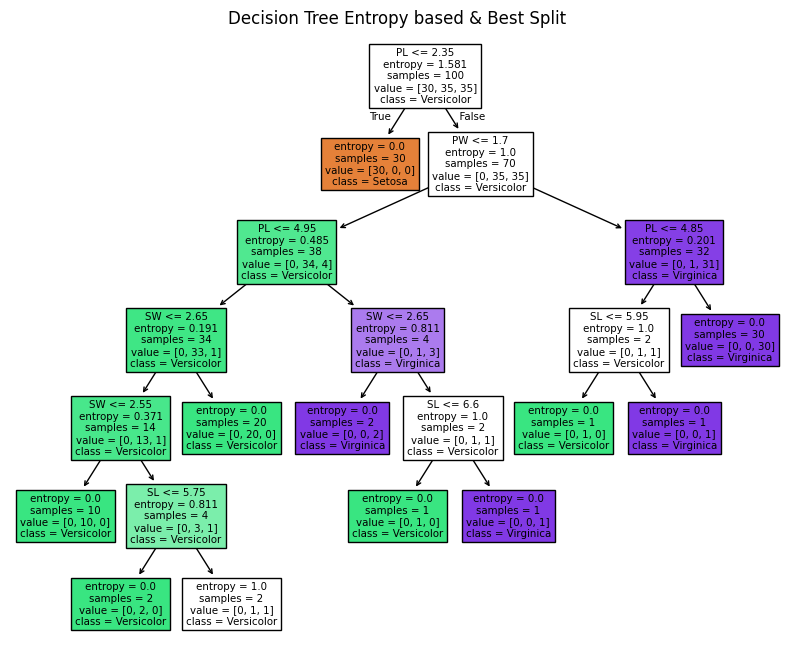

In [95]:
plt.figure(figsize=(10,8))
plot_tree(dt_entropybest,feature_names=X.columns,class_names=le.classes_,filled=True)
plt.title("Decision Tree Entropy based & Best Split")
plt.show()

**Entropy Based with Random Split:**


In [96]:
dt_entropyrandom = DecisionTreeClassifier(criterion="entropy",splitter="random",max_depth=3,random_state=42)
dt_entropyrandom.fit(X_train, y_train)
y_pred_entropyrandom = dt_entropyrandom.predict(X_test)
print("Entropy Random Split Accuracy:", accuracy_score(y_test, y_pred_entropyrandom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropyrandom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_entropyrandom))

Entropy Random Split Accuracy: 0.9545454545454546

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.95        44
   macro avg       0.96      0.96      0.96        44
weighted avg       0.95      0.95      0.95        44


Confusion Matrix:
 [[14  0  0]
 [ 0 14  1]
 [ 0  1 14]]


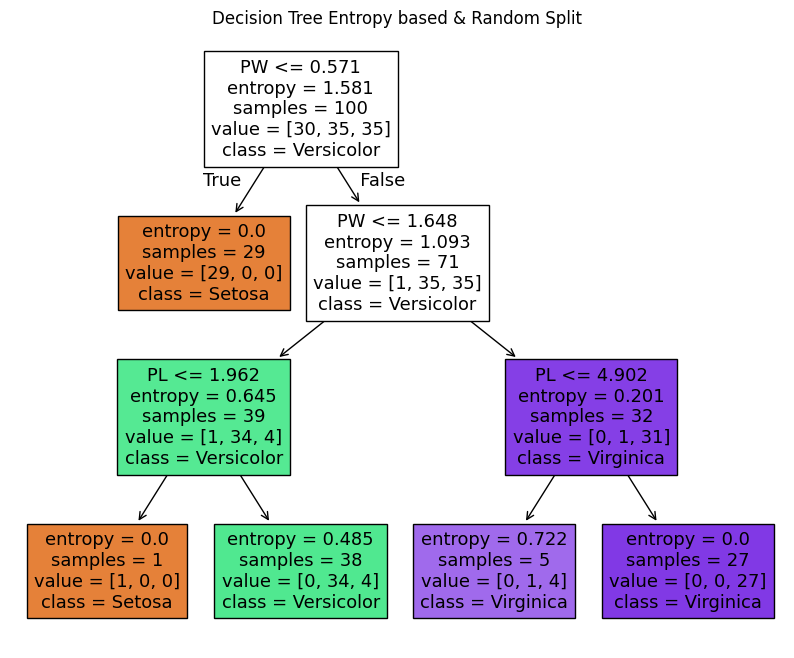

In [97]:
plt.figure(figsize=(10,8))
plot_tree(dt_entropyrandom ,feature_names=X.columns,class_names=le.classes_,filled=True)
plt.title("Decision Tree Entropy based & Random Split")
plt.show()